In [1]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(df['species_name'].value_counts())
print(df.head())

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


In [2]:
filtered = df[df['species_name'].isin(['versicolor', 'virginica'])]
filtered = filtered[['petal length (cm)', 'petal width (cm)', 'species_name']]

print(filtered.shape)
print(filtered['species_name'].value_counts())

(100, 3)
species_name
versicolor    50
virginica     50
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = filtered[['petal length (cm)', 'petal width (cm)']]
y = filtered['species_name'].map({'versicolor': 0, 'virginica': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 80
Test size: 20


In [4]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9


In [5]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[2.60092347 2.33626698]]
Intercept: [-16.74093025]


C:\Users\Abiram\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


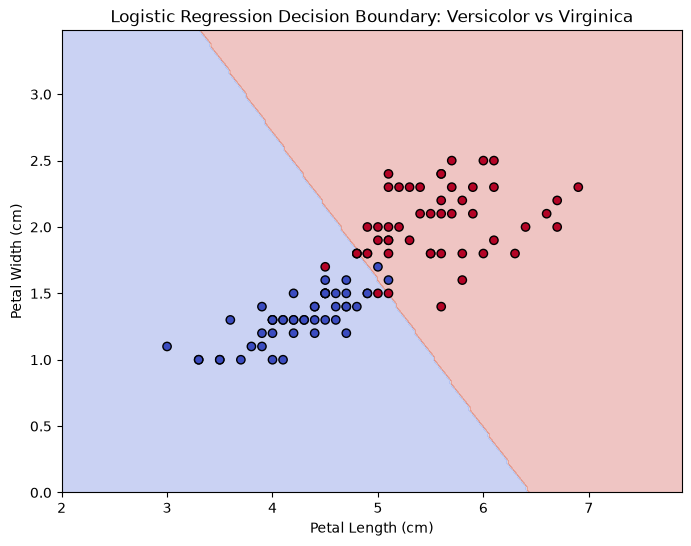

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = X['petal length (cm)'].min() - 1, X['petal length (cm)'].max() + 1
y_min, y_max = X['petal width (cm)'].min() - 1, X['petal width (cm)'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c=y, cmap='coolwarm', edgecolors='k')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Logistic Regression Decision Boundary: Versicolor vs Virginica')
plt.show()

Both numbers being positive means: bigger petals (longer or wider) make the model more likely to guess "virginica." Smaller petals make it guess "versicolor." Petal length matters a little more than petal width (2.60 vs 2.34).This matches what we see in the plot - virginica (red) flowers occupies the region with larger petal dimension